# Studying the June 2026 European heat wave with `earthlens`

In mid-to-late June 2026 a **heat dome parked over Western Europe** — daytime highs near 39 °C in
Madrid, then the heat rolling northeast into Paris and northern Italy over the following days. This
notebook shows how the [`earthlens`](https://github.com/serapeum-org/earthlens) facade lets you build a
**remote-sensing picture of that event from several providers through one uniform API**.

We work the way an analyst actually would — **synoptic first, then zoom**:

1. A **continental** air-temperature map of the whole heat dome.
2. Let the **data pick the hottest cities** (rather than guessing) — a ranking across major capitals.
3. **Zoom into the top three** with 1 km satellite land-surface temperature to see the urban heat island.
4. A **time series** showing the ridge *march* south-to-north, reaching the **Netherlands** last.
5. A **city-scale look** at the Randstad, then the heat's **human-health** cost — an ozone episode.
6. A test of the **antecedent-drought** hypothesis, plus pointers to the exposure layers.

Every layer is the same `EarthLens(...).download()` call — only the `data_source` key and a few
arguments change.

## The heat-wave toolbox inside `earthlens`

`earthlens` registers ~50 backends. Most are irrelevant to a heat wave, and two temperature imagers
are geographically wrong for Europe (`goes` → the Americas, `jaxa`/`himawari` → Asia-Pacific). The
keys that matter here:

| Heat-wave layer | Provider key(s) | Used below |
|-----------------|-----------------|:---------:|
| Air temperature (reanalysis) | `gee` (ERA5-Land), `ecmwf`, `amazon-s3` | ✅ |
| Satellite land-surface temperature | `gee` (MODIS), `eumetsat`, `usgs-landsat`, `cdse` | ✅ |
| Co-occurring drought | `drought` (Copernicus EDO), `chc` (SPI/SPEI) | ✅ |
| Human-health effect (air quality) | `openaq`, `eea-aq` | ✅ |
| Consequences (fire, WBGT stress) | `firms`, `chc` | discover |
| Exposure (people, built-up, admin) | `worldpop`, `ghsl`, `admin` | discover |

The live layers below use `gee` and `drought`; the rest are reachable exactly the same way.

## Setup

`pyramids` supplies `Dataset` for reading/plotting GeoTIFFs; `earthlens` supplies the `EarthLens`
facade. We define **three tiny helpers** up front — read a GeoTIFF into a unit-scaled masked array,
sample it at a point, and draw a map — so every teaching cell below stays two or three lines.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyramids.dataset import Dataset

from earthlens import EarthLens

2026-07-05 17:46:42 | INFO | pyramids.base.config | Logging is configured.


`read_field` masks the provider nodata, drops implausible fills below `valid_min`, then applies a `scale`/`offset` so raw sensor counts come back in physical units (°C).

In [2]:
def read_field(path, scale=1.0, offset=0.0, valid_min=None):
    ds = Dataset.read_file(str(path))
    arr = ds.read_array().astype("float64")
    if arr.ndim == 3:
        arr = arr[0]
    nodata = ds.no_data_value[0] if ds.no_data_value else None
    if nodata is not None:
        arr = np.ma.masked_equal(arr, nodata)
    if valid_min is not None:
        arr = np.ma.masked_less(arr, valid_min)
    return np.ma.masked_invalid(arr) * scale + offset, ds.bbox

`sample` reads one pixel at a lat/lon from a grid + its bounding box — used to rank cities.

In [3]:
def sample(grid, bbox, lat, lon):
    x_min, y_min, x_max, y_max = bbox
    rows, cols = grid.shape
    col = min(max(int((lon - x_min) / (x_max - x_min) * cols), 0), cols - 1)
    row = min(max(int((y_max - lat) / (y_max - y_min) * rows), 0), rows - 1)
    return float(grid[row, col])

In [4]:
def show(grid, bbox, title, label, ax=None, cmap="inferno", vmin=None, vmax=None):
    x_min, y_min, x_max, y_max = bbox
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(grid, extent=[x_min, x_max, y_min, y_max], origin="upper",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.figure.colorbar(im, ax=ax, label=label, shrink=0.85)
    ax.set_title(title); ax.set_xlabel("lon"); ax.set_ylabel("lat")
    if own:
        plt.tight_layout(); plt.show()

## Pin the event

The heat wave ran roughly **17–26 June 2026**, peaking over Iberia around the **22nd**. We fix the
window, a continental box, a list of candidate cities to rank, and 1° zoom boxes for the eventual focus
cities — so the whole notebook is deterministic.

In [5]:
START, END, PEAK = "2026-06-17", "2026-06-26", "20260622"
EUROPE = dict(lat_lim=[35.0, 58.0], lon_lim=[-10.0, 27.0])

CANDIDATES = {
    "Madrid": (40.42, -3.70), "Seville": (37.39, -5.99), "Barcelona": (41.39, 2.17),
    "Lisbon": (38.72, -9.14), "Paris": (48.85, 2.35), "London": (51.51, -0.13),
    "Milan": (45.46, 9.19), "Rome": (41.90, 12.50), "Berlin": (52.52, 13.40),
    "Vienna": (48.21, 16.37), "Zurich": (47.37, 8.54), "Athens": (37.98, 23.73),
    "Amsterdam": (52.37, 4.90), "Rotterdam": (51.92, 4.48), "Utrecht": (52.09, 5.12),
}
CITY_BOXES = {
    "Madrid": dict(lat_lim=[40.1, 40.7], lon_lim=[-4.0, -3.4]),
    "Paris": dict(lat_lim=[48.6, 49.1], lon_lim=[2.0, 2.7]),
    "Milan": dict(lat_lim=[45.2, 45.7], lon_lim=[9.0, 9.5]),
}
# The three Randstad cities, which the dome reached last (peak ~26 Jun).
DUTCH_BOXES = {
    "Amsterdam": dict(lat_lim=[52.30, 52.42], lon_lim=[4.80, 5.00]),
    "Rotterdam": dict(lat_lim=[51.87, 51.97], lon_lim=[4.40, 4.55]),
    "Utrecht": dict(lat_lim=[52.05, 52.15], lon_lim=[5.05, 5.20]),
}
OUT = Path("out") / "heatwave"
OUT.mkdir(parents=True, exist_ok=True)
START, END

('2026-06-17', '2026-06-26')

## Step 1 — Discover the providers

`EarthLens.DataSources` is the live registry of every backend key. Before writing a download, confirm
the heat-wave providers from the table above are all registered.

In [6]:
wanted = ["gee", "ecmwf", "chc", "drought", "firms", "eea-aq", "worldpop", "ghsl", "admin"]
pd.Series({k: k in EarthLens.DataSources for k in wanted}, name="registered")

gee         True
ecmwf       True
chc         True
drought     True
firms       True
eea-aq      True
worldpop    True
ghsl        True
admin       True
Name: registered, dtype: bool

`EarthLens.list_datasets(<key>)` lists a backend's catalogue. The Climate Hazards Center (`chc`) ships heat-stress products — WBGT and the CHIRTS daily maximum-temperature / heat-index series — over anonymous FTP, no credentials.

In [7]:
chc_ids = EarthLens.list_datasets("chc")
[d for d in chc_ids if any(k in d for k in ("wbgt", "chirtsdaily", "heat"))]

['chirtsdaily-heat-index',
 'chirtsdaily-relative-humidity',
 'chirtsdaily-svp',
 'chirtsdaily-tmax',
 'chirtsdaily-tmin',
 'chirtsdaily-vpd',
 'wbgt-dekad',
 'wbgt-monthly']

`EarthLens.describe_dataset(<key>, <id>)` returns the typed catalogue row. Here is the MODIS daily LST product we will zoom with — note the band name, unit (kelvin) and 0.02 scale factor.

In [8]:
mod11 = EarthLens.describe_dataset("gee", "MODIS/061/MOD11A1")
pd.DataFrame(
    [(b.id, b.units, b.scale, b.description) for b in mod11.bands.values()],
    columns=["band", "units", "scale", "description"],
).head()

,band,units,scale,description
0,LST_Day_1km,K,0.020,Daytime land surface temperature
1,LST_Night_1km,K,0.020,Nighttime land surface temperature
2,QC_Day,NaN,NaN,Daytime LST quality indicators
3,QC_Night,NaN,NaN,Nighttime LST quality indicators
4,Emis_31,NaN,0.002,Band 31 emissivity


## Step 2 — Credentials for Google Earth Engine

The temperature layers come from Earth Engine, which needs a **service account**. The notebook reads
the account e-mail and JSON key path from the `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` environment
variables — set both before running. The air-quality step (Step 8) additionally reads a free OpenAQ key
from `OPENAQ_API_KEY`. (`drought` needs no credentials.)

In [9]:
import os

SERVICE_ACCOUNT = os.environ["GEE_SERVICE_ACCOUNT"]
SERVICE_KEY = os.environ["GEE_SERVICE_KEY"]

## Step 3 — The heat dome (continental air temperature)

Start synoptic. ERA5-Land — ECMWF's reanalysis of near-surface **air temperature** — is hosted on Earth
Engine, so we fetch it through the same `gee` key and sidestep the Copernicus CDS queue. One daily-mean
`temperature_2m` GeoTIFF per day over the whole continent.

In [10]:
eu_job = EarthLens(
    data_source="gee",
    dataset="ECMWF/ERA5_LAND/DAILY_AGGR",
    variables=["temperature_2m"],
    start=START, end=END,
    temporal_resolution="daily",
    path=str(OUT / "europe"),
    export_via="url",
    **EUROPE,
)
eu_job.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
eu_paths = eu_job.download(progress_bar=False)
print(f"{len(eu_paths)} daily continental tiles")

2026-07-05 17:46:53.414 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260617.tif (165966 bytes)


2026-07-05 17:46:55.588 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260618.tif (167487 bytes)


2026-07-05 17:46:56.790 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260619.tif (167268 bytes)


2026-07-05 17:46:59.135 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260620.tif (167297 bytes)


2026-07-05 17:47:01.543 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260621.tif (167039 bytes)


...

2026-07-05 17:47:05.189 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260623.tif (167567 bytes)


2026-07-05 17:47:06.445 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260624.tif (167867 bytes)


2026-07-05 17:47:07.750 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260625.tif (167462 bytes)


2026-07-05 17:47:09.909 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\europe\ECMWF_ERA5_LAND_DAILY_AGGR_temperature_2m_20260626.tif (167447 bytes)


10 daily continental tiles


ERA5-Land temperature is in kelvin (fill 0); we mask non-positive fills and subtract 273.15. Map the peak day.

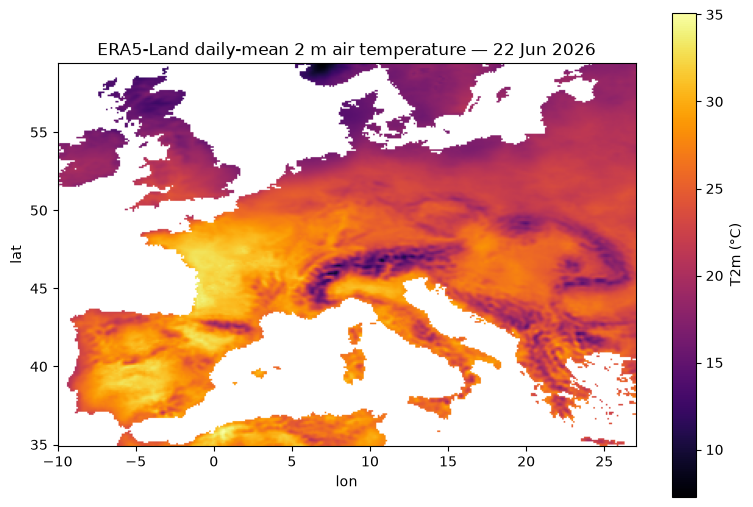

In [11]:
peak_path = next(p for p in eu_paths if p.stem.endswith(PEAK))
eu_grid, eu_bbox = read_field(peak_path, offset=-273.15, valid_min=1.0)
show(eu_grid, eu_bbox, "ERA5-Land daily-mean 2 m air temperature — 22 Jun 2026", "T2m (°C)")

The hot lobe sits squarely over **Iberia and France** — a daily *mean* above 30 °C (the days topped
39 °C, and crucially the nights stayed hot). Southeast Europe is comparatively mild: this is a
**Western**-European event, which is why we let the data, not intuition, choose the focus cities next.

## Step 4 — Let the data choose the cities

Rather than guess which cities to study, **sample the continental tiles** at a dozen major capitals and
take each city's hottest day in the window. The ranking picks the focus cities for us.

In [12]:
records = []
for path in sorted(eu_paths):
    grid, bbox = read_field(path, offset=-273.15, valid_min=1.0)
    day = pd.to_datetime(path.stem.split("_")[-1])
    for name, (lat, lon) in CANDIDATES.items():
        records.append({"date": day, "city": name, "t2m_C": sample(grid, bbox, lat, lon)})
city_temps = pd.DataFrame(records)
peaks = city_temps.groupby("city")["t2m_C"].max().sort_values(ascending=False)
peaks.round(1)

C:\Users\main\AppData\Local\Temp\ipykernel_27240\3419766565.py:6: UserWarning: Warning: converting a masked element to nan.
  return float(grid[row, col])


city
Paris        32.2
Madrid       30.5
Milan        30.2
Seville      29.8
Vienna       29.0
Rome         28.8
Utrecht      28.7
Zurich       28.3
Rotterdam    27.9
Athens       27.5
Berlin       27.3
Amsterdam    27.2
London       27.2
Lisbon       23.0
Barcelona     NaN
Name: t2m_C, dtype: float64

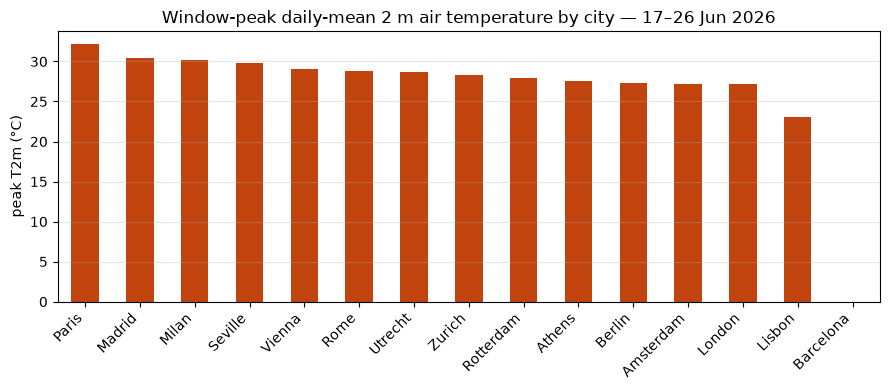

In [13]:
ax = peaks.plot.bar(figsize=(9, 4), color="#c1440e")
ax.set_title("Window-peak daily-mean 2 m air temperature by city — 17–26 Jun 2026")
ax.set_ylabel("peak T2m (°C)"); ax.set_xlabel("")
plt.xticks(rotation=45, ha="right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Paris, Madrid and Milan** top the ranking (Seville just behind; Barcelona's coastal pixel is masked)
— the Iberia → France → N-Italy footprint of the heat dome. Those three become our zoom targets.

## Step 5 — Zoom in: satellite land-surface temperature

Air temperature tells you the region; **land surface temperature (LST)** — the 1 km skin temperature
MODIS measures directly — reveals the *urban heat island*, where dark, dry city fabric bakes far hotter
than the air. We pull a few days around the peak for each focus city (some passes are cloud-gapped) and
keep the hottest clear tile.

In [14]:
city_lst = {}
for name, box in CITY_BOXES.items():
    job = EarthLens(
        data_source="gee",
        dataset="MODIS/061/MOD11A1",
        variables=["LST_Day_1km"],
        start="2026-06-20", end="2026-06-25",
        temporal_resolution="daily",
        path=str(OUT / "lst" / name),
        export_via="url",
        **box,
    )
    job.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    city_lst[name] = job.download(progress_bar=False)
{k: len(v) for k, v in city_lst.items()}

2026-07-05 17:47:12.765 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Madrid\MODIS_061_MOD11A1_LST_Day_1km_20260620.tif (10196 bytes)


2026-07-05 17:47:13.951 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Madrid\MODIS_061_MOD11A1_LST_Day_1km_20260621.tif (9816 bytes)


2026-07-05 17:47:15.477 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Madrid\MODIS_061_MOD11A1_LST_Day_1km_20260622.tif (5206 bytes)


2026-07-05 17:47:16.956 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Madrid\MODIS_061_MOD11A1_LST_Day_1km_20260623.tif (10149 bytes)


2026-07-05 17:47:18.761 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Madrid\MODIS_061_MOD11A1_LST_Day_1km_20260624.tif (9233 bytes)


...

2026-07-05 17:47:33.701 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Milan\MODIS_061_MOD11A1_LST_Day_1km_20260622.tif (7301 bytes)


2026-07-05 17:47:34.538 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Milan\MODIS_061_MOD11A1_LST_Day_1km_20260623.tif (6419 bytes)


2026-07-05 17:47:35.301 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Milan\MODIS_061_MOD11A1_LST_Day_1km_20260624.tif (7265 bytes)


2026-07-05 17:47:36.492 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst\Milan\MODIS_061_MOD11A1_LST_Day_1km_20260625.tif (6617 bytes)


{'Madrid': 6, 'Paris': 6, 'Milan': 6}

MODIS stores LST as counts (valid ≥ 7500) scaling by 0.02 into kelvin. For each city we pick the tile with the hottest area-mean and map the three side by side.

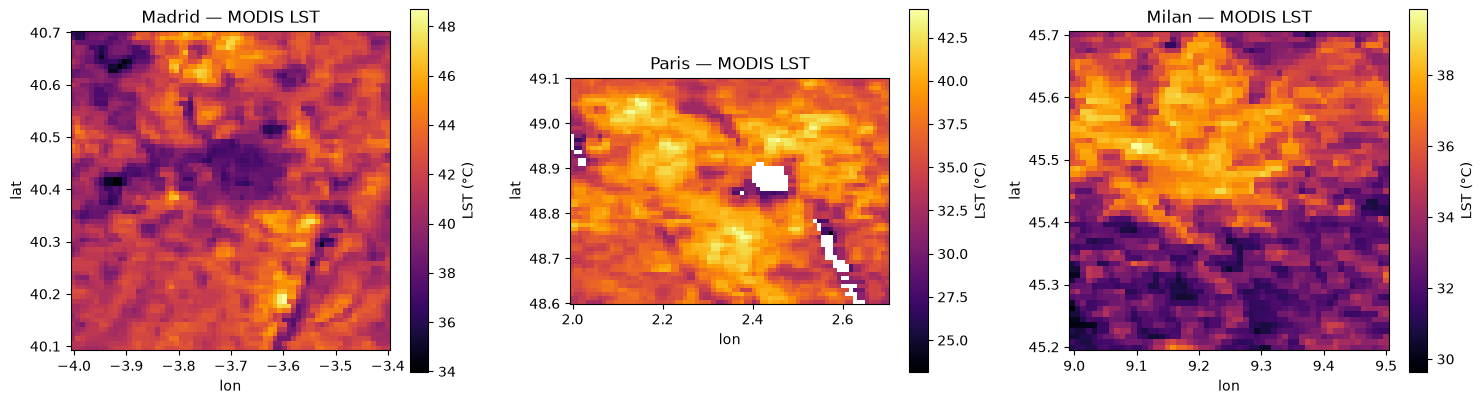

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, paths) in zip(axes, city_lst.items()):
    tiles = [read_field(p, scale=0.02, offset=-273.15, valid_min=7500) for p in paths]
    grid, bbox = max(tiles, key=lambda gb: gb[0].mean())
    show(grid, bbox, f"{name} — MODIS LST", "LST (°C)", ax=ax)
plt.tight_layout(); plt.show()

Each city core glows well above **40 °C** at the surface — far hotter than the ~30 °C daily-mean air
temperature — with the hottest pixels over the dense built-up centre, the classic urban-heat-island
signature that a single weather station would miss.

## Step 6 — Watch the heat dome migrate

Because we sampled every daily tile at every city, we already have the time series. We plot a clean
**south-to-north transect** — Madrid (40°N), Paris (49°N), Amsterdam (52°N) — to watch the ridge march
poleward.

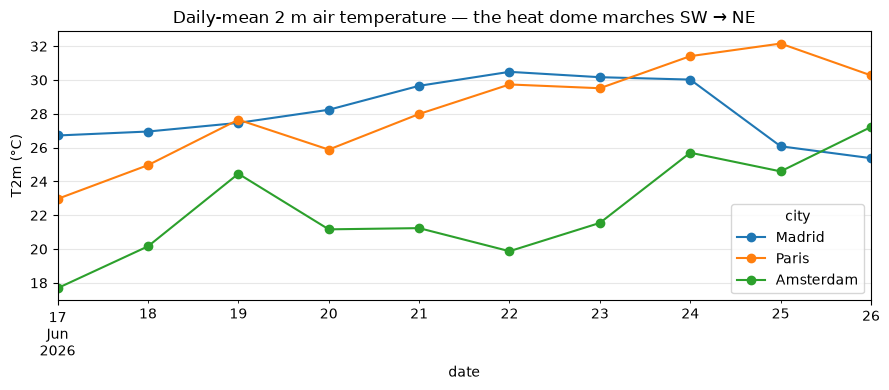

In [16]:
transect = ["Madrid", "Paris", "Amsterdam"]
wide = city_temps[city_temps.city.isin(transect)].pivot(index="date", columns="city", values="t2m_C")
ax = wide[transect].plot(marker="o", figsize=(9, 4))
ax.set_title("Daily-mean 2 m air temperature — the heat dome marches SW → NE")
ax.set_ylabel("T2m (°C)"); ax.set_xlabel("date"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The peak walks north with the calendar: **Madrid** hottest around the 22nd, **Paris** overtaking it by
the 24th–25th, and **Amsterdam** only catching up on the **26th** — the last day of the window. That
lag *is* the heat wave propagating across the continent, and it is why the Netherlands, on the dome's
northern edge, is worth a closer look next.

## Step 7 — The heat reaches the Netherlands

The dome's northern edge swept over the **Randstad** on the 26th. We zoom into **Amsterdam, Rotterdam
and Utrecht** with the same MODIS LST call, over the 24–27 June tail of the event.

In [17]:
dutch_lst = {}
for name, box in DUTCH_BOXES.items():
    job = EarthLens(
        data_source="gee",
        dataset="MODIS/061/MOD11A1",
        variables=["LST_Day_1km"],
        start="2026-06-24", end="2026-06-27",
        temporal_resolution="daily",
        path=str(OUT / "lst_nl" / name),
        export_via="url",
        **box,
    )
    job.authenticate(service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    dutch_lst[name] = job.download(progress_bar=False)
{k: len(v) for k, v in dutch_lst.items()}

2026-07-05 17:47:39.442 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Amsterdam\MODIS_061_MOD11A1_LST_Day_1km_20260624.tif (1542 bytes)


2026-07-05 17:47:40.009 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Amsterdam\MODIS_061_MOD11A1_LST_Day_1km_20260625.tif (1555 bytes)


2026-07-05 17:47:42.007 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Amsterdam\MODIS_061_MOD11A1_LST_Day_1km_20260626.tif (1496 bytes)


2026-07-05 17:47:42.568 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Amsterdam\MODIS_061_MOD11A1_LST_Day_1km_20260627.tif (915 bytes)


2026-07-05 17:47:45.822 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Rotterdam\MODIS_061_MOD11A1_LST_Day_1km_20260624.tif (1344 bytes)


...

2026-07-05 17:47:50.021 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Utrecht\MODIS_061_MOD11A1_LST_Day_1km_20260624.tif (1352 bytes)


2026-07-05 17:47:50.680 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Utrecht\MODIS_061_MOD11A1_LST_Day_1km_20260625.tif (1387 bytes)


2026-07-05 17:47:51.493 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Utrecht\MODIS_061_MOD11A1_LST_Day_1km_20260626.tif (1345 bytes)


2026-07-05 17:47:53.109 | INFO     | earthlens.gee.backend:_download_one_url_tile:910 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\lst_nl\Utrecht\MODIS_061_MOD11A1_LST_Day_1km_20260627.tif (915 bytes)


{'Amsterdam': 4, 'Rotterdam': 4, 'Utrecht': 4}

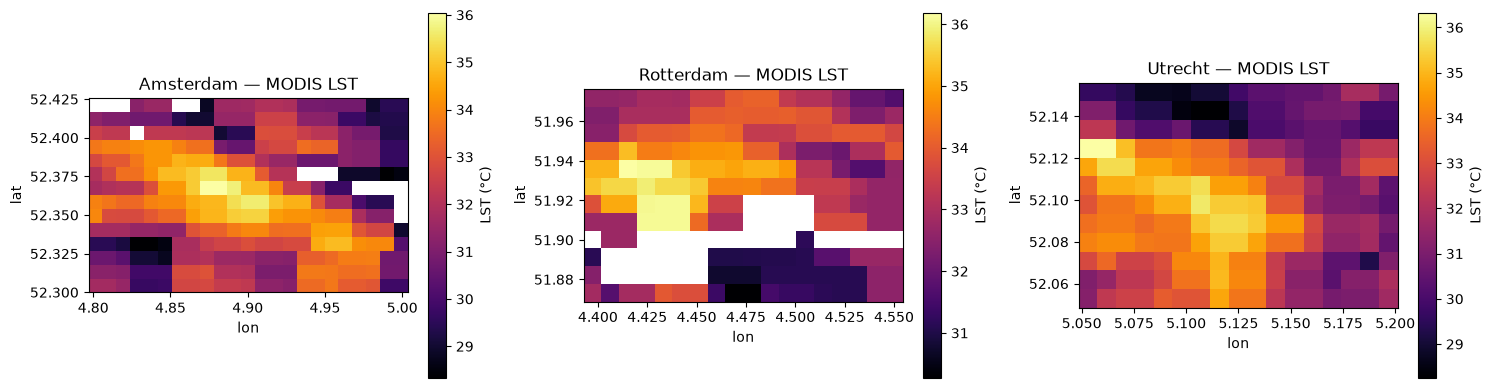

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, paths) in zip(axes, dutch_lst.items()):
    tiles = [read_field(p, scale=0.02, offset=-273.15, valid_min=7500) for p in paths]
    grid, bbox = max(tiles, key=lambda gb: gb[0].mean())
    show(grid, bbox, f"{name} — MODIS LST", "LST (°C)", ax=ax)
plt.tight_layout(); plt.show()

Surface temperatures in the low-to-mid **30s °C** across all three Randstad cities — cooler than
Iberia's peak, but this is the dome's *poleward extreme*, arriving days after Madrid. The hottest
pixels again sit over the dense city fabric, with the surrounding water and polders staying markedly
cooler.

## Step 8 — The heat's effect on people: an ozone episode

Satellites image the *environment*; the clearest **human-health** effect of a heat wave shows up in the
**ground** network instead. Stagnant, hot, sunny air cooks traffic and industrial emissions into
**ground-level ozone** — the photochemical smog behind heat-wave health advisories, when the elderly,
children and people with asthma are told to limit outdoor activity. We pull daily ozone from the
**OpenAQ** ground stations over the Netherlands (a tabular `DataFrame`, not a raster). OpenAQ needs a
free key, read from the `OPENAQ_API_KEY` environment variable.

In [19]:
ozone = EarthLens(
    data_source="openaq",
    variables=["o3"],
    temporal_resolution="daily",
    start=START, end=END,
    lat_lim=[51.5, 52.6], lon_lim=[4.0, 5.5],
    path=str(OUT / "ozone"),
    max_locations=25,
).download(progress_bar=False)
print(f"{ozone.station_id.nunique()} stations, {len(ozone)} daily ozone readings")

2026-07-05 17:47:54.259 | WARNING  | earthlens.openaq.backend:_search:350 - OpenAQ search hit the max_locations=25 cap; the result may be partial. Raise max_locations= or shrink the bbox / date window to capture every station.


2026-07-05 17:48:02.171 | INFO     | earthlens.openaq.backend:download:487 - OpenAQ download summary: 170 measurement(s) across 17 sensor(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\heatwave\docs\examples\heatwave\out\heatwave\ozone\openaq_o3_20260617_20260626.csv


17 stations, 170 daily ozone readings


Reduce the stations to a daily regional mean, and pull the Randstad air temperature from the `city_temps` table we already built, so we can plot ozone against the heat.

In [20]:
ozone["date"] = pd.to_datetime(ozone["datetime_utc"]).dt.tz_localize(None).dt.normalize()
o3_daily = ozone.groupby("date")["value"].mean()
nl_temp = (city_temps[city_temps.city.isin(["Amsterdam", "Rotterdam", "Utrecht"])]
           .groupby("date")["t2m_C"].mean())
o3_daily.round(0)

date
2026-06-16     32.0
2026-06-17     46.0
2026-06-18     83.0
2026-06-19     55.0
2026-06-20     28.0
2026-06-21     57.0
2026-06-22     69.0
2026-06-23    108.0
2026-06-24    122.0
2026-06-25    115.0
Name: value, dtype: float64

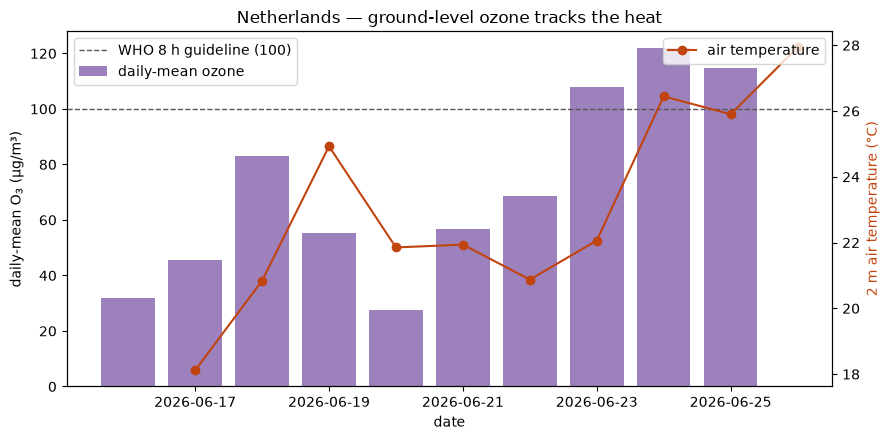

In [21]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(o3_daily.index, o3_daily.values, color="#8c6bb1", alpha=0.85)
ax1.axhline(100, color="#555", ls="--", lw=1)
ax1.set_ylabel("daily-mean O$_3$ (µg/m³)"); ax1.set_xlabel("date")
ax1.set_title("Netherlands — ground-level ozone tracks the heat")
ax1.legend(["WHO 8 h guideline (100)", "daily-mean ozone"], loc="upper left")
ax2 = ax1.twinx()
ax2.plot(nl_temp.index, nl_temp.values, color="#c1440e", marker="o")
ax2.set_ylabel("2 m air temperature (°C)", color="#c1440e")
ax2.legend(["air temperature"], loc="upper right")
plt.tight_layout(); plt.show()

Ground-level ozone more than **tripled** — from ~30 µg/m³ before the event to ~120 µg/m³ on 23–25 June —
rising and falling *with the air temperature* and peaking exactly as the dome sat over the Netherlands.
Daily-mean concentrations climbed past the **WHO 100 µg/m³ 8-hour guideline** level, at which health
authorities issue smog advisories. This is the tangible human cost of the heat — and, unlike the
thermal maps above, it comes from OpenAQ's *ground* network, the honest place to measure it. (For
wildfires, the other heat consequence, see the `firms` backend.)

## Step 9 — Did drought amplify the heat?

Heat and drought often reinforce each other: dry ground can't evaporate, so incoming energy goes
straight into heating the surface. Worth *testing* rather than assuming. The `drought` backend serves
the **Copernicus European Drought Observatory (EDO)** — no credentials. We pull its short-term
**Standardized Precipitation Index** (`edo-spaST`, a categorical anomaly product; class 0 = near-normal)
over Iberia for two windows: the **winter before** the event and the **event window itself**.

In [22]:
spi = {}
for tag, (s, e) in {"Feb 2026": ("2026-02-01", "2026-02-12"),
                    "Jun 2026": ("2026-06-01", "2026-06-12")}.items():
    paths = EarthLens(
        data_source="edo",
        dataset="edo-spaST",
        variables=[],
        start=s, end=e,
        lat_lim=[36.0, 48.0], lon_lim=[-10.0, 6.0],
        path=str(OUT / "spi"),
    ).download(progress_bar=False)
    spi[tag] = paths[-1]
{k: v.name for k, v in spi.items()}

2026-07-05 17:48:13.522 | INFO     | earthlens.drought.backend:download:791 - EDO/GDO: Copernicus European/Global Drought Observatory (EMS) — free reuse with attribution to Copernicus EMS.


2026-07-05 17:48:24.509 | INFO     | earthlens.drought.backend:download:791 - EDO/GDO: Copernicus European/Global Drought Observatory (EMS) — free reuse with attribution to Copernicus EMS.


{'Feb 2026': 'edo-spaST_20260211.tif', 'Jun 2026': 'edo-spaST_20260611.tif'}

The two panels share a colour scale so they are directly comparable. (The backend now clips each EDO raster to the requested box — it previously returned a full −180…180 strip because the Copernicus server ignores the longitude subset.)

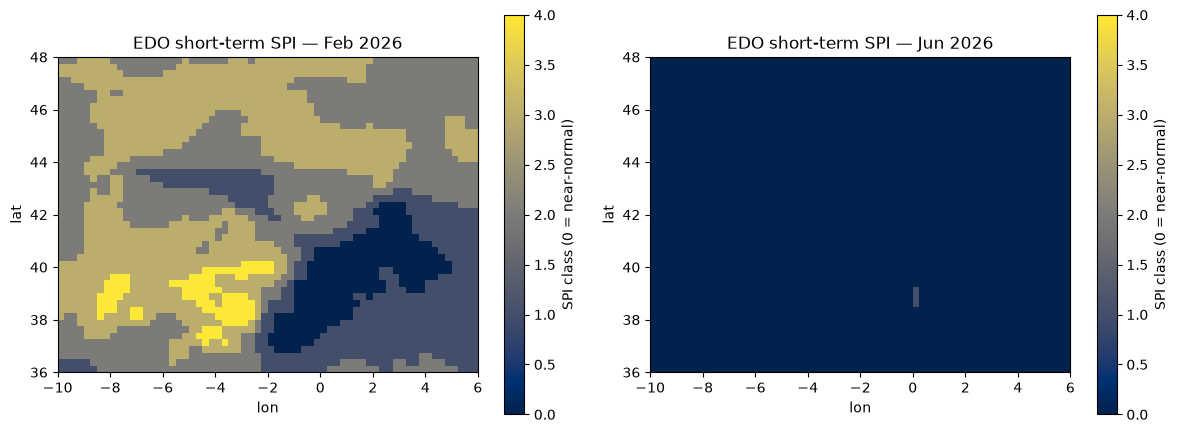

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (tag, path) in zip(axes, spi.items()):
    grid, bbox = read_field(path)
    show(grid, bbox, f"EDO short-term SPI — {tag}", "SPI class (0 = near-normal)",
         ax=ax, cmap="cividis", vmin=0, vmax=4)
plt.tight_layout(); plt.show()

Iberia carried **widespread non-zero SPI anomaly classes in February**, but by the **June** event
window the index had relaxed to near-normal (class 0) almost everywhere. So the observations *reject*
the antecedent-drought hypothesis for this particular heat wave — it was driven mainly by an
atmospheric heat ridge, not by parched soils. That is exactly the kind of assumption a remote-sensing
layer lets you check. (The richer EDO indicators — soil-moisture anomaly, combined drought indicator —
lag by weeks and weren't yet published for mid-2026.)

## Step 10 — Who is exposed?

The final layer is **impact** — overlaying the hot zone on where people and cities are. `earthlens`
exposes three exposure backends, reached exactly like the ones above; each returns population rasters,
built-up-area rasters, or admin polygons you can clip to the same boxes and zonal-average against the
temperature maps.

In [24]:
exposure = ["worldpop", "ghsl", "admin"]
pd.Series({k: EarthLens.DataSources[k].__name__ for k in exposure}, name="backend_class")

worldpop           WorldPop
ghsl                   GHSL
admin       AdminBoundaries
Name: backend_class, dtype: str

## Takeaway

From one facade you reconstructed the June 2026 Western-European heat wave, synoptic to local:

- **`gee` → ERA5-Land** — the continental heat dome over Iberia and France.
- **A data-driven ranking** — the observations, not a guess, chose Madrid / Paris / Milan.
- **`gee` → MODIS LST** — 1 km urban-heat-island detail, surface > 40 °C, far above the air temperature.
- **A migration time series** — the ridge marching SW → NE, reaching the **Netherlands** (Amsterdam /
  Rotterdam / Utrecht) last, on the final day.
- **`openaq` → ground-level ozone** — the heat's human-health cost: an ozone episode over the
  Netherlands that tripled with the temperature and passed the WHO guideline.
- **`drought` → EDO SPI** — a winter-vs-event comparison that *tested* (and rejected) the
  antecedent-drought hypothesis for this event.
- **`worldpop` / `ghsl` / `admin`** — the exposure layers to turn temperature into impact.

Every layer used the same `EarthLens(data_source=..., start=..., end=..., lat_lim=..., lon_lim=...)`
→ `.download()` pattern. **To extend**: swap the key — `firms` for wildfire hot-spots, `eea-aq` for
EEA-validated air quality, `chc` for the WBGT human-heat-stress index, or `eumetsat` for 15-minute
Meteosat imagery of the same days. Discover any of them with `EarthLens.list_datasets(<key>)` and
`EarthLens.describe_dataset(<key>, <id>)`.